In [ ]:
# ── Deep Learning ──────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, ConcatDataset
import torchvision.transforms as transforms

# ── Datos y procesamiento ──────────────────────────────
import numpy as np
from PIL import Image
import os
import json
import random
from tqdm import tqdm

# ── Visualización ──────────────────────────────────────
import matplotlib.pyplot as plt

# ── Métricas ───────────────────────────────────────────
from sklearn.metrics import jaccard_score

# ── Verificar GPU disponible ───────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Librerías cargadas")
print(f"🖥️  Dispositivo: {device}")

✅ Librerías cargadas
🖥️  Dispositivo: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ── Rutas base ─────────────────────────────────────────
BASE         = '/content/drive/MyDrive/trazos'
DATASET_BASE = os.path.join(BASE, 'dataset', 'fase1_entrenamiento')

PATH_BASICA  = os.path.join(DATASET_BASE, 'geometria_basica')
PATH_RUIDO   = os.path.join(DATASET_BASE, 'ruido')
PATH_MODELOS = os.path.join(BASE, 'modelos', 'fase1')
PATH_LOGS    = os.path.join(BASE, 'logs')

# ── Verificar que existen ──────────────────────────────
rutas = [PATH_BASICA, PATH_RUIDO, PATH_MODELOS, PATH_LOGS]
for r in rutas:
    estado = "✅" if os.path.exists(r) else "❌ NO EXISTE"
    print(f"{estado} — {r}")

Mounted at /content/drive
✅ — /content/drive/MyDrive/trazos/dataset/fase1_entrenamiento/geometria_basica
✅ — /content/drive/MyDrive/trazos/dataset/fase1_entrenamiento/ruido
✅ — /content/drive/MyDrive/trazos/modelos/fase1
✅ — /content/drive/MyDrive/trazos/logs


In [ ]:
class TrazosDataset(Dataset):
    """
    Lee pares (input, mask) desde una carpeta con estructura:
        fase/split/inputs/
        fase/split/masks/
    """
    def __init__(self, fase_dir, split, img_size=256):
        self.dir_input = os.path.join(fase_dir, split, 'inputs')
        self.dir_mask  = os.path.join(fase_dir, split, 'masks')
        self.img_size  = img_size
        self.archivos  = sorted(os.listdir(self.dir_input))

        self.transform_img = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5, 0.5, 0.5],
                                 [0.5, 0.5, 0.5])
        ])
        self.transform_mask = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.archivos)

    def __getitem__(self, idx):
        nombre = self.archivos[idx]
        img  = Image.open(os.path.join(self.dir_input, nombre)).convert('RGB')
        mask = Image.open(os.path.join(self.dir_mask,  nombre)).convert('L')
        return self.transform_img(img), self.transform_mask(mask)


# ── Combinar datasets ──────────────────────────────────
train_basica  = TrazosDataset(PATH_BASICA, 'train')
train_ruido   = TrazosDataset(PATH_RUIDO,  'train')
train_dataset = ConcatDataset([train_basica, train_ruido])

val_basica    = TrazosDataset(PATH_BASICA, 'val')
val_ruido     = TrazosDataset(PATH_RUIDO,  'val')
val_dataset   = ConcatDataset([val_basica, val_ruido])

test_basica   = TrazosDataset(PATH_BASICA, 'test')
test_ruido    = TrazosDataset(PATH_RUIDO,  'test')
test_dataset  = ConcatDataset([test_basica, test_ruido])

print(f"✅ Dataset cargado")
print(f"   Train : {len(train_dataset):>5} imágenes")
print(f"   Val   : {len(val_dataset):>5} imágenes")
print(f"   Test  : {len(test_dataset):>5} imágenes")
print(f"   Total : {len(train_dataset)+len(val_dataset)+len(test_dataset):>5} imágenes")

✅ Dataset cargado
   Train :  2000 imágenes
   Val   :   400 imágenes
   Test  :   400 imágenes
   Total :  2800 imágenes


In [ ]:
BATCH_SIZE  = 16
NUM_WORKERS = 2

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

print(f"✅ DataLoaders listos")
print(f"   Batches train : {len(train_loader)}")
print(f"   Batches val   : {len(val_loader)}")
print(f"   Batches test  : {len(test_loader)}")

✅ DataLoaders listos
   Batches train : 125
   Batches val   : 25
   Batches test  : 25


In [ ]:
# Cargar log de v1
log_v1_path = os.path.join(PATH_LOGS, 'v1_cnn_baseline.json')

with open(log_v1_path, 'r') as f:
    log_v1 = json.load(f)

V1_TEST_IOU  = 0.5833   # resultado real de v1
V1_TEST_DICE = 0.7363
BASELINE_IOU = 0.0555   # baseline Canny de v1

print("=" * 50)
print("📊 REFERENCIA v1_cnn_baseline")
print("=" * 50)
print(f"   Baseline Canny IoU : {BASELINE_IOU:.4f}")
print(f"   Test IoU           : {V1_TEST_IOU:.4f}")
print(f"   Test Dice          : {V1_TEST_DICE:.4f}")
print()
print("   🎯 v2 U-Net debe superar estos valores")
print("=" * 50)

📊 REFERENCIA v1_cnn_baseline
   Baseline Canny IoU : 0.0555
   Test IoU           : 0.5833
   Test Dice          : 0.7363

   🎯 v2 U-Net debe superar estos valores


In [ ]:
class DobleConv(nn.Module):
    """
    Bloque base de U-Net: dos convoluciones seguidas de BatchNorm y ReLU.
    BatchNorm estabiliza el entrenamiento y acelera la convergencia.
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.bloque = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.bloque(x)


class UNet(nn.Module):
    """
    U-Net para segmentación estructural.
    Input:  [B, 3, 256, 256] — imagen RGB normalizada
    Output: [B, 1, 256, 256] — mask de probabilidades

    Canales: 3 → 64 → 128 → 256 → 512 → 1024 (bottleneck)
             luego se expande de vuelta con skip connections
    """
    def __init__(self, in_ch=3, out_ch=1, features=[64, 128, 256, 512]):
        super().__init__()

        self.encoder = nn.ModuleList()
        self.pool    = nn.MaxPool2d(2, 2)
        self.decoder = nn.ModuleList()

        # ── Encoder ────────────────────────────────────
        ch = in_ch
        for f in features:
            self.encoder.append(DobleConv(ch, f))
            ch = f

        # ── Bottleneck ─────────────────────────────────
        self.bottleneck = DobleConv(features[-1], features[-1] * 2)

        # ── Decoder ────────────────────────────────────
        for f in reversed(features):
            # ConvTranspose2d: sube resolución x2
            self.decoder.append(nn.ConvTranspose2d(f * 2, f, 2, stride=2))
            # DobleConv: refina con la skip connection concatenada
            self.decoder.append(DobleConv(f * 2, f))

        # ── Capa final ─────────────────────────────────
        self.final = nn.Conv2d(features[0], out_ch, 1)

    def forward(self, x):
        skips = []

        # Encoder — guardar skip connections
        for enc in self.encoder:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]  # invertir para emparejar con decoder

        # Decoder — usar skip connections
        for i in range(0, len(self.decoder), 2):
            x     = self.decoder[i](x)       # subir resolución
            skip  = skips[i // 2]

            # Si hay diferencia de tamaño por redondeo
            if x.shape != skip.shape:
                x = torch.nn.functional.interpolate(
                    x, size=skip.shape[2:], mode='bilinear', align_corners=False
                )

            x = torch.cat([skip, x], dim=1)  # concatenar skip
            x = self.decoder[i + 1](x)       # refinar

        return torch.sigmoid(self.final(x))


# ── Crear modelo ───────────────────────────────────────
modelo = UNet().to(device)

total_params = sum(p.numel() for p in modelo.parameters() if p.requires_grad)
print(f"✅ U-Net creada")
print(f"   Parámetros entrenables: {total_params:,}")
print(f"   v1 CNN tenía         :     33,937")
print(f"   → U-Net es más grande pero mucho más precisa")

✅ U-Net creada
   Parámetros entrenables: 31,037,633
   v1 CNN tenía         :     33,937
   → U-Net es más grande pero mucho más precisa


In [ ]:
def calcular_iou(pred, target, threshold=0.5):
    """
    Intersection over Union.
    Valor 0 = sin overlap | 1 = perfecto
    """
    pred  = (pred > threshold).float()
    inter = (pred * target).sum()
    union = (pred + target).clamp(0, 1).sum()
    return (inter / (union + 1e-8)).item()

def calcular_dice(pred, target, threshold=0.5):
    """
    Dice Score — penaliza fuertemente falsos positivos y negativos.
    Valor 0 = sin overlap | 1 = perfecto
    """
    pred  = (pred > threshold).float()
    inter = (pred * target).sum()
    return (2 * inter / (pred.sum() + target.sum() + 1e-8)).item()

print("✅ Métricas definidas: IoU, Dice Score")

✅ Métricas definidas: IoU, Dice Score


In [ ]:
# ── Loss ───────────────────────────────────────────────
# BCELoss: mismo que v1 para comparación directa
criterion = nn.BCELoss()

# ── Optimizer ──────────────────────────────────────────
optimizer = optim.Adam(modelo.parameters(), lr=1e-3)

# ── Scheduler ──────────────────────────────────────────
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ── Configuración general ──────────────────────────────
CONFIG = {
    'version'      : 'v2_unet',
    'epochs'       : 50,
    'batch_size'   : BATCH_SIZE,
    'lr'           : 1e-3,
    'img_size'     : 256,
    'optimizer'    : 'Adam',
    'loss'         : 'BCELoss',
    'patience'     : 10,
    'arquitectura' : 'U-Net features=[64,128,256,512]',
}

print("✅ Configuración lista")
for k, v in CONFIG.items():
    print(f"   {k:15}: {v}")

✅ Configuración lista
   version        : v2_unet
   epochs         : 50
   batch_size     : 16
   lr             : 0.001
   img_size       : 256
   optimizer      : Adam
   loss           : BCELoss
   patience       : 10
   arquitectura   : U-Net features=[64,128,256,512]


In [ ]:
def entrenar(modelo, train_loader, val_loader, config, path_modelo, path_log):

    mejor_val_loss = float('inf')
    mejor_val_iou  = 0.0
    epochs_sin_mejora = 0
    historial = {
        'train_loss': [], 'val_loss': [],
        'val_iou'   : [], 'val_dice': []
    }

    for epoch in range(config['epochs']):

        # ── TRAIN ──────────────────────────────────────
        modelo.train()
        train_loss_total = 0

        for imgs, masks in train_loader:
            imgs  = imgs.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            preds = modelo(imgs)
            loss  = criterion(preds, masks)
            loss.backward()
            optimizer.step()
            train_loss_total += loss.item()

        train_loss = train_loss_total / len(train_loader)

        # ── VALIDACIÓN ─────────────────────────────────
        modelo.eval()
        val_loss_total = 0
        iou_total      = 0
        dice_total     = 0

        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs  = imgs.to(device)
                masks = masks.to(device)
                preds = modelo(imgs)

                val_loss_total += criterion(preds, masks).item()
                iou_total      += calcular_iou(preds, masks)
                dice_total     += calcular_dice(preds, masks)

        val_loss = val_loss_total / len(val_loader)
        val_iou  = iou_total      / len(val_loader)
        val_dice = dice_total     / len(val_loader)

        # ── Scheduler ──────────────────────────────────
        scheduler.step(val_loss)

        # ── Guardar historial ──────────────────────────
        historial['train_loss'].append(train_loss)
        historial['val_loss']  .append(val_loss)
        historial['val_iou']   .append(val_iou)
        historial['val_dice']  .append(val_dice)

        # ── Log por época ──────────────────────────────
        print(f"Época {epoch+1:03d}/{config['epochs']} | "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"IoU: {val_iou:.4f} | "
              f"Dice: {val_dice:.4f}")

        # ── Guardar mejor modelo por loss ──────────────
        if val_loss < mejor_val_loss:
            mejor_val_loss = val_loss
            epochs_sin_mejora = 0
            torch.save(modelo.state_dict(),
                       os.path.join(path_modelo, f"{config['version']}_best_loss.pth"))
            print(f"           💾 Mejor loss guardado ({mejor_val_loss:.4f})")
        else:
            epochs_sin_mejora += 1

        # ── Guardar mejor modelo por IoU ───────────────
        if val_iou > mejor_val_iou:
            mejor_val_iou = val_iou
            torch.save(modelo.state_dict(),
                       os.path.join(path_modelo, f"{config['version']}_best_iou.pth"))
            print(f"           🎯 Mejor IoU guardado  ({mejor_val_iou:.4f})")

        # ── EarlyStopping ──────────────────────────────
        if epochs_sin_mejora >= config['patience']:
            print(f"\n⛔ EarlyStopping en época {epoch+1}")
            break

    # ── Guardar log completo ───────────────────────────
    log = {
        'config'         : config,
        'historial'      : historial,
        'mejor_val_loss' : mejor_val_loss,
        'mejor_val_iou'  : mejor_val_iou
    }
    with open(os.path.join(path_log, f"{config['version']}.json"), 'w') as f:
        json.dump(log, f, indent=4)

    print(f"\n✅ Entrenamiento finalizado")
    print(f"   Mejor Val Loss : {mejor_val_loss:.4f}")
    print(f"   Mejor Val IoU  : {mejor_val_iou:.4f}")
    print(f"   Log guardado   : {config['version']}.json")

    return historial


# ── Ejecutar ───────────────────────────────────────────
historial = entrenar(modelo, train_loader, val_loader, CONFIG, PATH_MODELOS, PATH_LOGS)

Época 001/50 | Train Loss: 0.2075 | Val Loss: 0.0690 | IoU: 0.6409 | Dice: 0.7771
           💾 Mejor loss guardado (0.0690)
           🎯 Mejor IoU guardado  (0.6409)
Época 002/50 | Train Loss: 0.0437 | Val Loss: 0.0274 | IoU: 0.7321 | Dice: 0.8413
           💾 Mejor loss guardado (0.0274)
           🎯 Mejor IoU guardado  (0.7321)
Época 003/50 | Train Loss: 0.0225 | Val Loss: 0.0175 | IoU: 0.8279 | Dice: 0.9045
           💾 Mejor loss guardado (0.0175)
           🎯 Mejor IoU guardado  (0.8279)
Época 004/50 | Train Loss: 0.0139 | Val Loss: 0.0111 | IoU: 0.8527 | Dice: 0.9195
           💾 Mejor loss guardado (0.0111)
           🎯 Mejor IoU guardado  (0.8527)
Época 005/50 | Train Loss: 0.0100 | Val Loss: 0.0103 | IoU: 0.8503 | Dice: 0.9182
           💾 Mejor loss guardado (0.0103)
Época 006/50 | Train Loss: 0.0083 | Val Loss: 0.0084 | IoU: 0.8596 | Dice: 0.9236
           💾 Mejor loss guardado (0.0084)
           🎯 Mejor IoU guardado  (0.8596)
Época 007/50 | Train Loss: 0.0068 | Val Loss: 

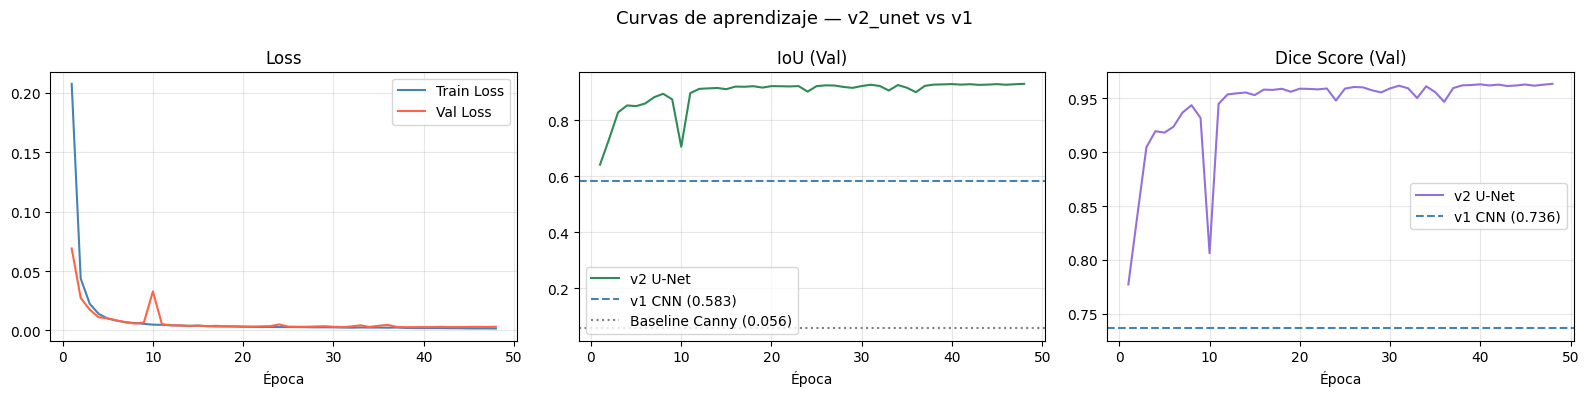

💾 Curvas guardadas en logs/


In [ ]:
def graficar_curvas_comparativa(historial, config, v1_iou, v1_dice):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f'Curvas de aprendizaje — {config["version"]} vs v1', fontsize=13)
    epochs = range(1, len(historial['train_loss']) + 1)

    # ── Loss ───────────────────────────────────────────
    axes[0].plot(epochs, historial['train_loss'], label='Train Loss', color='steelblue')
    axes[0].plot(epochs, historial['val_loss'],   label='Val Loss',   color='tomato')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Época')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ── IoU ────────────────────────────────────────────
    axes[1].plot(epochs, historial['val_iou'], color='seagreen', label='v2 U-Net')
    axes[1].axhline(y=v1_iou,      color='steelblue', linestyle='--',
                    label=f'v1 CNN ({v1_iou:.3f})')
    axes[1].axhline(y=BASELINE_IOU, color='gray',      linestyle=':',
                    label=f'Baseline Canny ({BASELINE_IOU:.3f})')
    axes[1].set_title('IoU (Val)')
    axes[1].set_xlabel('Época')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # ── Dice ───────────────────────────────────────────
    axes[2].plot(epochs, historial['val_dice'], color='mediumpurple', label='v2 U-Net')
    axes[2].axhline(y=v1_dice, color='steelblue', linestyle='--',
                    label=f'v1 CNN ({v1_dice:.3f})')
    axes[2].set_title('Dice Score (Val)')
    axes[2].set_xlabel('Época')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(PATH_LOGS, f"{config['version']}_curvas.png"), dpi=100)
    plt.show()
    print(f"💾 Curvas guardadas en logs/")

graficar_curvas_comparativa(historial, CONFIG, V1_TEST_IOU, V1_TEST_DICE)

In [ ]:
# Cargar mejor modelo por IoU
modelo.load_state_dict(
    torch.load(os.path.join(PATH_MODELOS, f"{CONFIG['version']}_best_iou.pth"))
)
modelo.eval()

test_loss_total = 0
iou_total       = 0
dice_total      = 0

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs  = imgs.to(device)
        masks = masks.to(device)
        preds = modelo(imgs)

        test_loss_total += criterion(preds, masks).item()
        iou_total       += calcular_iou(preds, masks)
        dice_total      += calcular_dice(preds, masks)

test_loss = test_loss_total / len(test_loader)
test_iou  = iou_total       / len(test_loader)
test_dice = dice_total      / len(test_loader)

print("=" * 55)
print("📊 EVALUACIÓN FINAL EN TEST — v2 U-Net")
print("=" * 55)
print(f"   Test Loss  : {test_loss:.4f}")
print(f"   Test IoU   : {test_iou:.4f}  (v1 CNN: {V1_TEST_IOU:.4f})")
print(f"   Test Dice  : {test_dice:.4f}  (v1 CNN: {V1_TEST_DICE:.4f})")
print()
mejora_iou  = test_iou  - V1_TEST_IOU
mejora_dice = test_dice - V1_TEST_DICE
simbolo_iou  = "✅ +" if mejora_iou  > 0 else "❌ "
simbolo_dice = "✅ +" if mejora_dice > 0 else "❌ "
print(f"   Mejora IoU  : {simbolo_iou}{mejora_iou:.4f}")
print(f"   Mejora Dice : {simbolo_dice}{mejora_dice:.4f}")
print("=" * 55)

📊 EVALUACIÓN FINAL EN TEST — v2 U-Net
   Test Loss  : 0.0032
   Test IoU   : 0.9299  (v1 CNN: 0.5833)
   Test Dice  : 0.9635  (v1 CNN: 0.7363)

   Mejora IoU  : ✅ +0.3466
   Mejora Dice : ✅ +0.2272


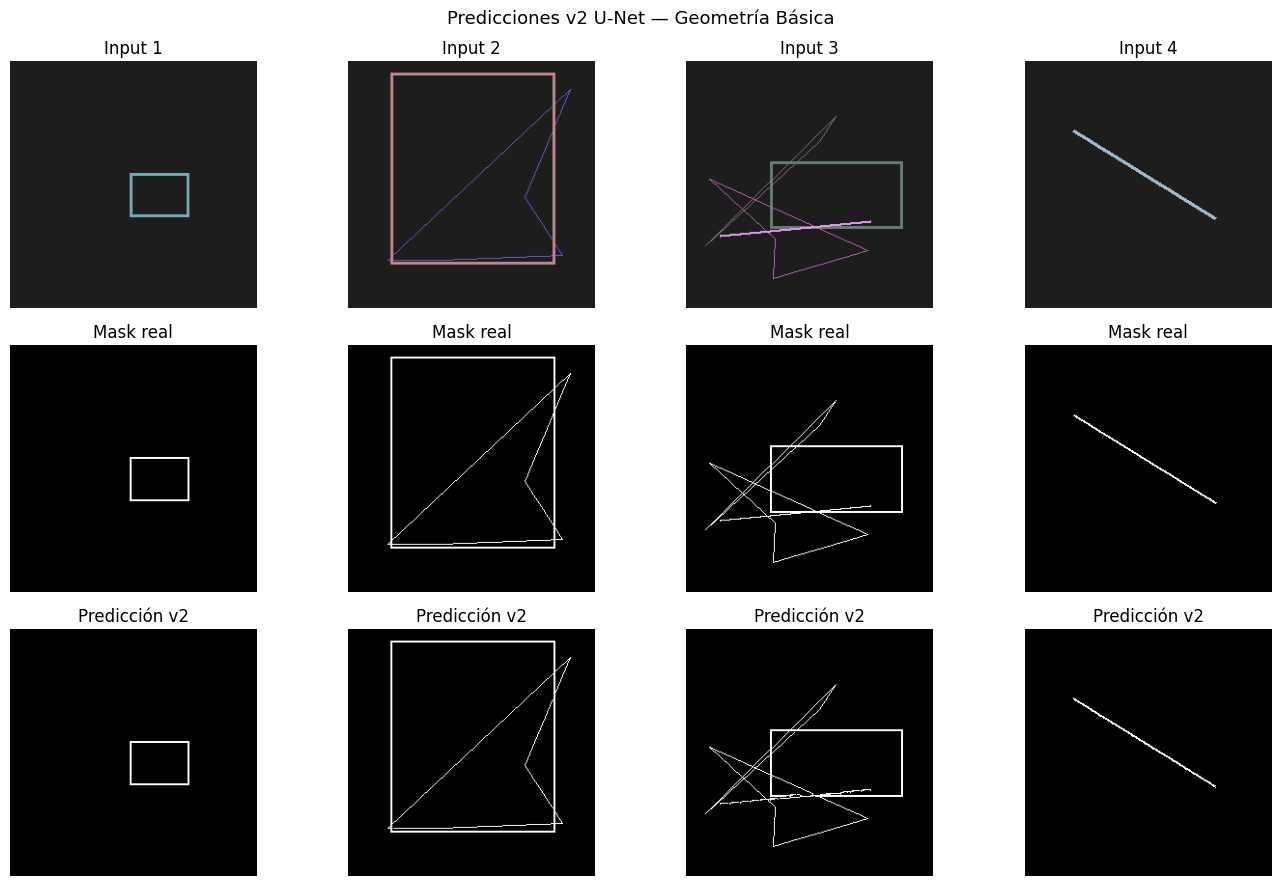

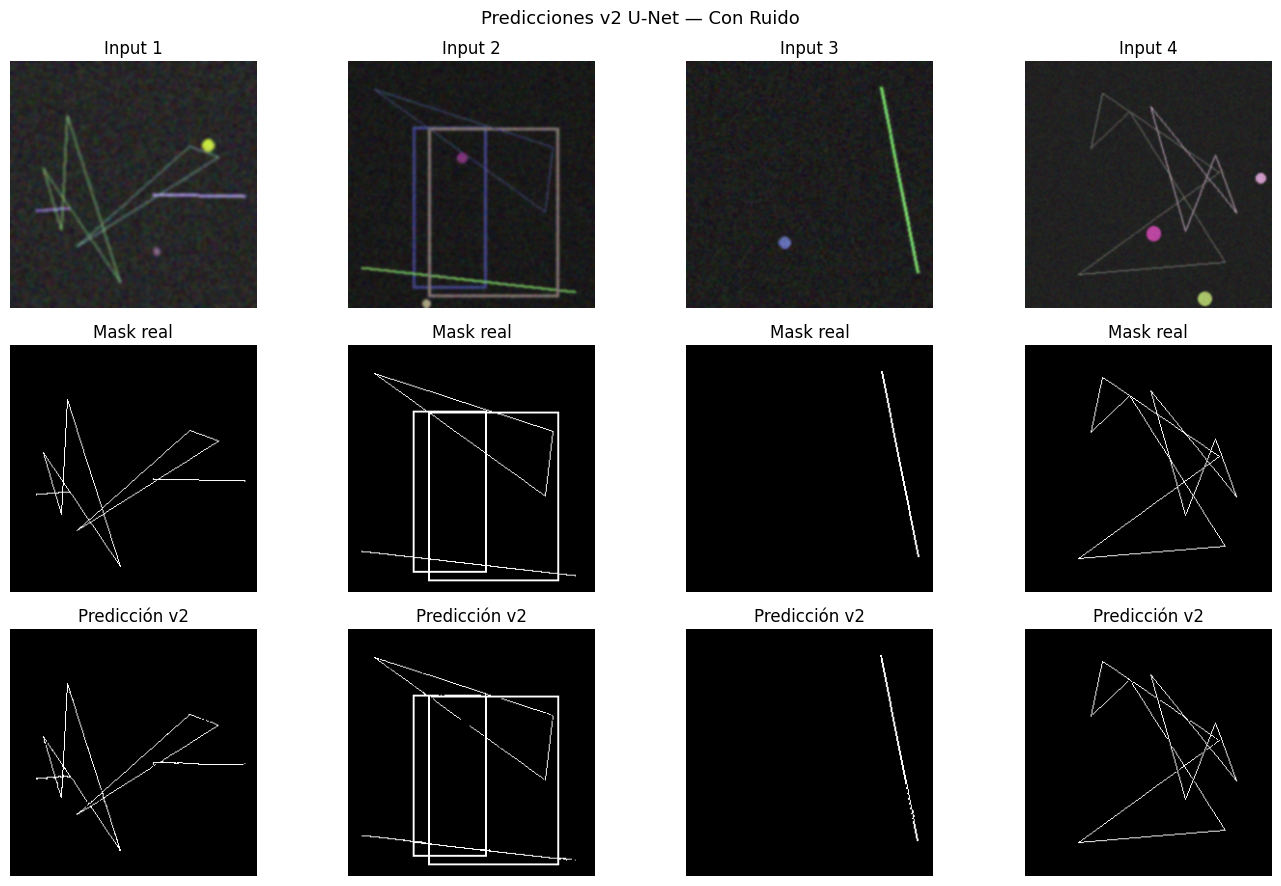

In [ ]:
def visualizar_predicciones(modelo, dataset, titulo, n=4, threshold=0.5):
    modelo.eval()
    indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(3, n, figsize=(14, 9))
    fig.suptitle(titulo, fontsize=13)

    with torch.no_grad():
        for col, idx in enumerate(indices):
            img_tensor, mask_tensor = dataset[idx]
            pred = modelo(img_tensor.unsqueeze(0).to(device))
            pred = pred.squeeze().cpu().numpy()

            img_np   = img_tensor.permute(1, 2, 0).numpy()
            img_np   = (img_np * 0.5 + 0.5).clip(0, 1)
            mask_np  = mask_tensor.squeeze().numpy()
            pred_bin = (pred > threshold).astype(np.float32)

            axes[0][col].imshow(img_np)
            axes[0][col].set_title(f'Input {col+1}')
            axes[0][col].axis('off')

            axes[1][col].imshow(mask_np, cmap='gray')
            axes[1][col].set_title('Mask real')
            axes[1][col].axis('off')

            axes[2][col].imshow(pred_bin, cmap='gray')
            axes[2][col].set_title('Predicción v2')
            axes[2][col].axis('off')

    plt.tight_layout()
    plt.show()

visualizar_predicciones(modelo, test_basica, 'Predicciones v2 U-Net — Geometría Básica')
visualizar_predicciones(modelo, test_ruido,  'Predicciones v2 U-Net — Con Ruido')

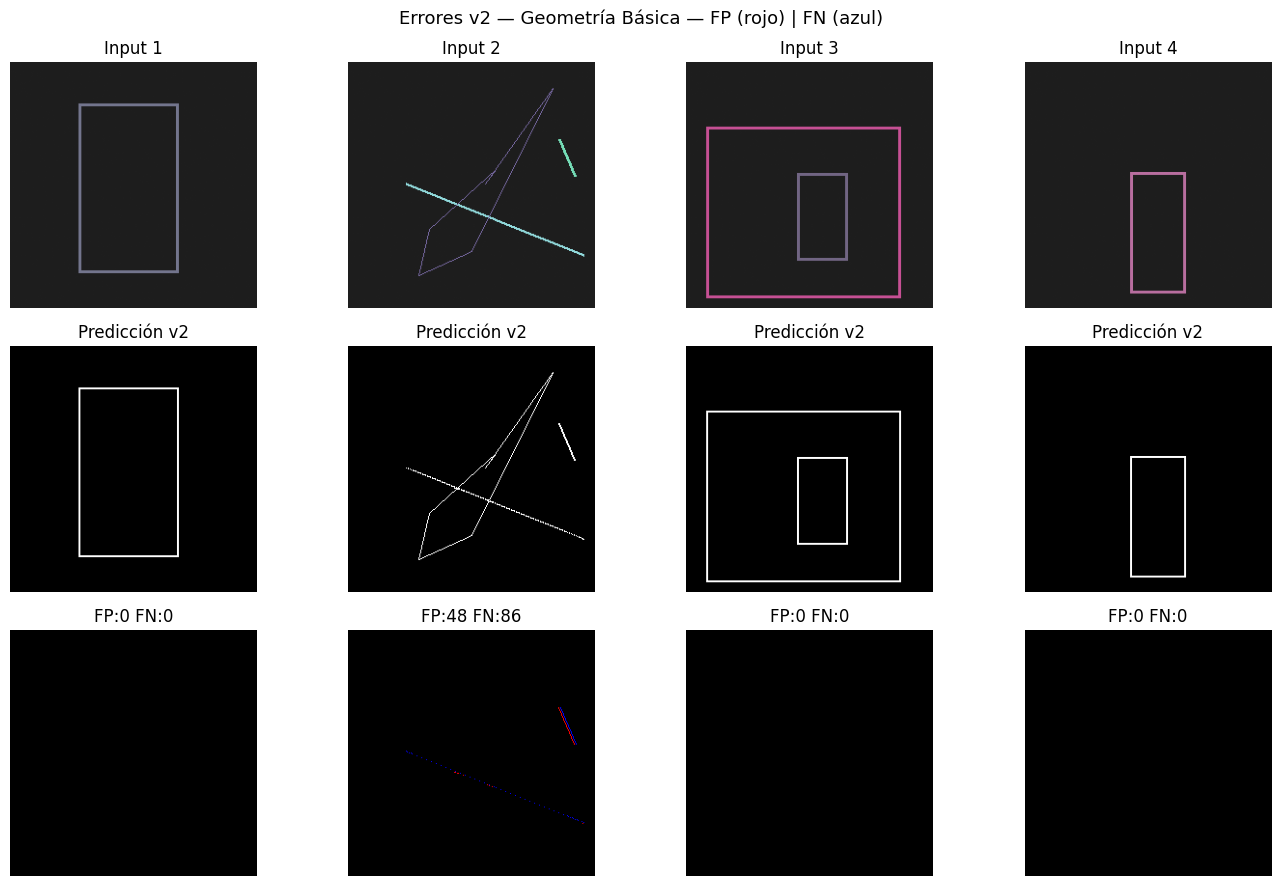

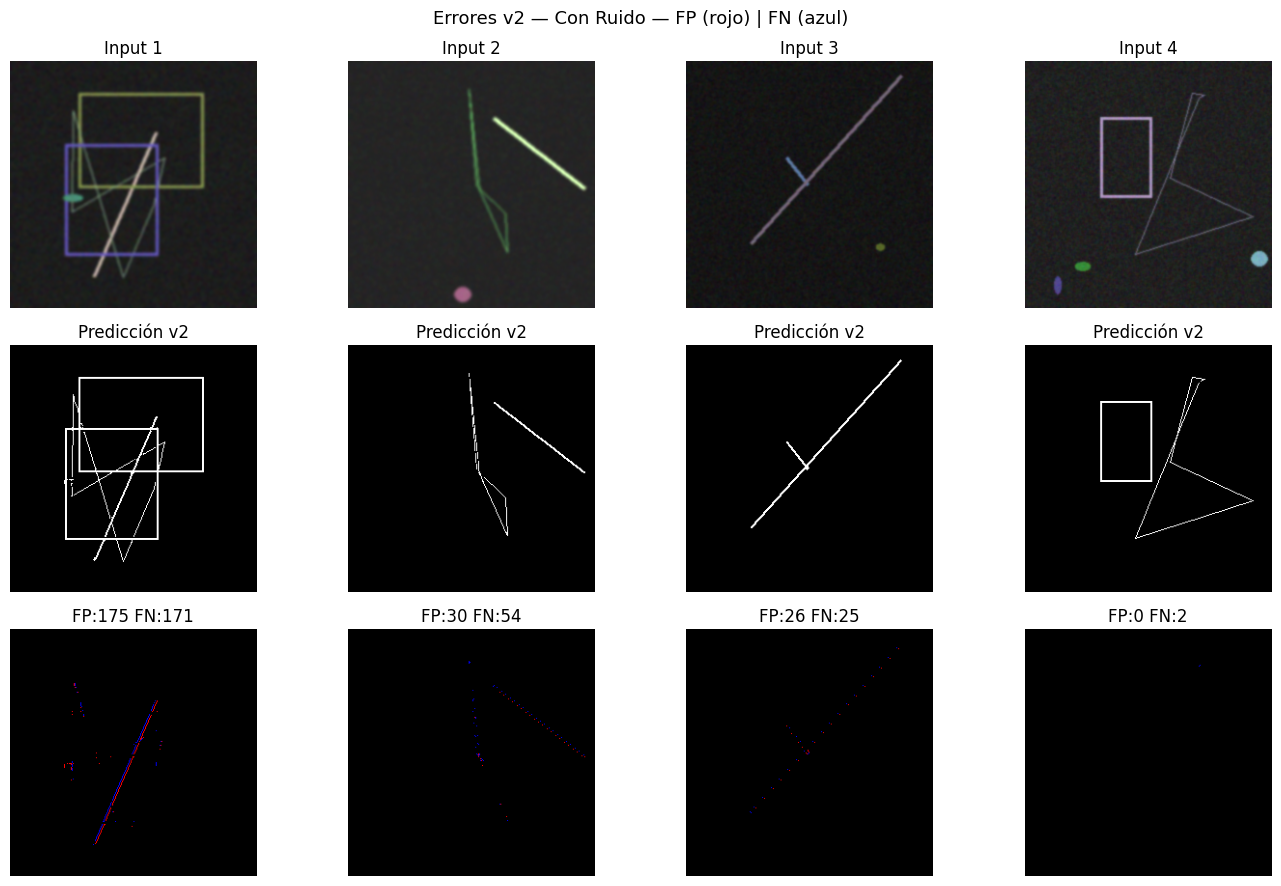

In [ ]:
def analizar_errores(modelo, dataset, titulo, n=4, threshold=0.5):
    modelo.eval()
    indices = random.sample(range(len(dataset)), n)

    fig, axes = plt.subplots(3, n, figsize=(14, 9))
    fig.suptitle(f'{titulo} — FP (rojo) | FN (azul)', fontsize=13)

    with torch.no_grad():
        for col, idx in enumerate(indices):
            img_tensor, mask_tensor = dataset[idx]
            pred = modelo(img_tensor.unsqueeze(0).to(device))
            pred = pred.squeeze().cpu().numpy()

            mask_np  = mask_tensor.squeeze().numpy()
            pred_bin = (pred > threshold).astype(np.float32)
            gt_bin   = (mask_np > 0.5).astype(np.float32)

            fp = ((pred_bin == 1) & (gt_bin == 0)).astype(np.float32)
            fn = ((pred_bin == 0) & (gt_bin == 1)).astype(np.float32)

            error_img = np.zeros((*gt_bin.shape, 3))
            error_img[:, :, 0] = fp   # rojo = FP
            error_img[:, :, 2] = fn   # azul = FN

            img_np = img_tensor.permute(1, 2, 0).numpy()
            img_np = (img_np * 0.5 + 0.5).clip(0, 1)

            axes[0][col].imshow(img_np)
            axes[0][col].set_title(f'Input {col+1}')
            axes[0][col].axis('off')

            axes[1][col].imshow(pred_bin, cmap='gray')
            axes[1][col].set_title('Predicción v2')
            axes[1][col].axis('off')

            axes[2][col].imshow(error_img)
            fp_count = int(fp.sum())
            fn_count = int(fn.sum())
            axes[2][col].set_title(f'FP:{fp_count} FN:{fn_count}')
            axes[2][col].axis('off')

    plt.tight_layout()
    plt.show()

analizar_errores(modelo, test_basica, 'Errores v2 — Geometría Básica')
analizar_errores(modelo, test_ruido,  'Errores v2 — Con Ruido')

In [ ]:
comparativa = {
    'Métrica'        : ['Baseline Canny', 'v1 CNN', 'v2 U-Net', 'Mejora v1→v2'],
    'IoU'            : [
        f"{BASELINE_IOU:.4f}",
        f"{V1_TEST_IOU:.4f}",
        f"{test_iou:.4f}",
        f"{'+' if test_iou > V1_TEST_IOU else ''}{test_iou - V1_TEST_IOU:.4f}"
    ],
    'Dice'           : [
        '—',
        f"{V1_TEST_DICE:.4f}",
        f"{test_dice:.4f}",
        f"{'+' if test_dice > V1_TEST_DICE else ''}{test_dice - V1_TEST_DICE:.4f}"
    ],
}

print("=" * 55)
print("📋 COMPARATIVA v1 vs v2")
print("=" * 55)
print(f"{'Modelo':<20} {'IoU':>10} {'Dice':>10}")
print("-" * 45)
for i in range(len(comparativa['Métrica'])):
    print(f"{comparativa['Métrica'][i]:<20} "
          f"{comparativa['IoU'][i]:>10} "
          f"{comparativa['Dice'][i]:>10}")
print("=" * 55)

# Guardar comparativa
with open(os.path.join(PATH_LOGS, 'comparativa_versiones.json'), 'w') as f:
    json.dump({
        'v1_cnn'  : {'iou': V1_TEST_IOU,  'dice': V1_TEST_DICE},
        'v2_unet' : {'iou': test_iou,      'dice': test_dice},
        'baseline': {'iou': BASELINE_IOU,  'dice': None}
    }, f, indent=4)

print(f"\n💾 Comparativa guardada en logs/comparativa_versiones.json")

📋 COMPARATIVA v1 vs v2
Modelo                      IoU       Dice
---------------------------------------------
Baseline Canny           0.0555          —
v1 CNN                   0.5833     0.7363
v2 U-Net                 0.9299     0.9635
Mejora v1→v2            +0.3466    +0.2272

💾 Comparativa guardada en logs/comparativa_versiones.json


In [21]:
def inferencia(ruta_imagen, modelo, threshold=0.5, img_size=256):
    """
    Recibe la ruta de cualquier imagen y devuelve
    la imagen original con el overlay estructural superpuesto.
    """
    modelo.eval()

    img = Image.open(ruta_imagen).convert('RGB')
    transform = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = modelo(img_tensor).squeeze().cpu().numpy()

    pred_bin = (pred > threshold).astype(np.float32)
    img_np   = np.array(img.resize((img_size, img_size))) / 255.0

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle('Inferencia as_built — v2 U-Net', fontsize=13)

    axes[0].imshow(img_np)
    axes[0].set_title('Imagen original')
    axes[0].axis('off')

    axes[1].imshow(pred_bin, cmap='gray')
    axes[1].set_title('Overlay predicho')
    axes[1].axis('off')

    overlay = img_np.copy()
    overlay[pred_bin == 1] = [0, 1, 0]   # verde = estructura detectada
    axes[2].imshow(overlay)
    axes[2].set_title('Overlay superpuesto')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    return pred_bin

# ── Ejemplo de uso ─────────────────────────────────────
# resultado = inferencia('/ruta/a/tu/imagen.png', modelo)
print("✅ Función de inferencia lista")
print("   Uso: inferencia('/imagenes_de_ejemplo/Estanteria 2.png', modelo)")

✅ Función de inferencia lista
   Uso: inferencia('/imagenes_de_ejemplo/Estanteria 2.png', modelo)


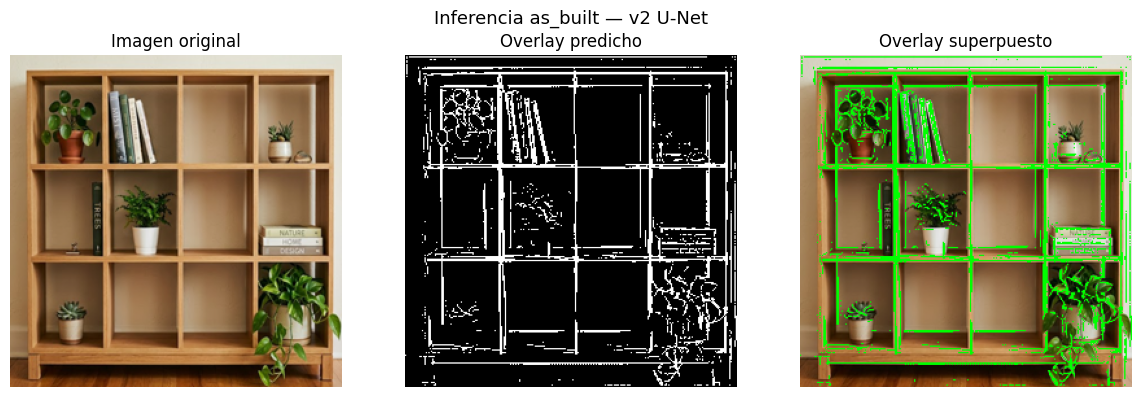

In [23]:
resultado = inferencia(
    '/content/drive/MyDrive/trazos/imagenes_de_ejemplo/Estanteria 2.png',
    modelo
)

In [ ]:
resumen_version = """
=======================================================
RESUMEN — as_built | {version}
=======================================================

QUÉ CAMBIÓ RESPECTO A v1:
- Arquitectura: CNN simple → U-Net con skip connections
- Se agregó BatchNorm en cada bloque convolucional
- Se guarda mejor modelo por IoU además de por loss
- Curvas comparativas muestran v1 como referencia

RESULTADOS:
- Baseline Canny IoU : {baseline}
- v1 CNN IoU         : {v1_iou}
- v2 U-Net IoU       : {test_iou}
- v2 U-Net Dice      : {test_dice}
- Mejora IoU v1→v2   : {mejora_iou}
- Mejora Dice v1→v2  : {mejora_dice}

QUÉ FUNCIONÓ:
- (completar después de ver resultados)

QUÉ NO FUNCIONÓ:
- (completar después de ver resultados)

ANÁLISIS VISUAL:
- ¿Los bordes son más limpios que v1?    (completar)
- ¿Las líneas son más continuas?         (completar)
- ¿Bajaron los FP y FN en los bordes?   (completar)

PRÓXIMA VERSIÓN v3:
- Si v2 mejora visualmente → ajustar hiperparámetros
- Si v2 no mejora → revisar loss function (Dice Loss)
- Evaluar agregar augmentations más agresivas
=======================================================
""".format(
    version    = CONFIG['version'],
    baseline   = f"{BASELINE_IOU:.4f}",
    v1_iou     = f"{V1_TEST_IOU:.4f}",
    test_iou   = f"{test_iou:.4f}",
    test_dice  = f"{test_dice:.4f}",
    mejora_iou = f"{'+' if test_iou  > V1_TEST_IOU  else ''}{test_iou  - V1_TEST_IOU:.4f}",
    mejora_dice= f"{'+' if test_dice > V1_TEST_DICE else ''}{test_dice - V1_TEST_DICE:.4f}",
)

print(resumen_version)

with open(os.path.join(PATH_LOGS, f"{CONFIG['version']}_notas.txt"), 'w') as f:
    f.write(resumen_version)

print("💾 Notas guardadas en logs/")


RESUMEN — as_built | v2_unet

QUÉ CAMBIÓ RESPECTO A v1:
- Arquitectura: CNN simple → U-Net con skip connections
- Se agregó BatchNorm en cada bloque convolucional
- Se guarda mejor modelo por IoU además de por loss
- Curvas comparativas muestran v1 como referencia

RESULTADOS:
- Baseline Canny IoU : 0.0555
- v1 CNN IoU         : 0.5833
- v2 U-Net IoU       : 0.9299
- v2 U-Net Dice      : 0.9635
- Mejora IoU v1→v2   : +0.3466
- Mejora Dice v1→v2  : +0.2272

QUÉ FUNCIONÓ:
- (completar después de ver resultados)

QUÉ NO FUNCIONÓ:
- (completar después de ver resultados)

ANÁLISIS VISUAL:
- ¿Los bordes son más limpios que v1?    (completar)
- ¿Las líneas son más continuas?         (completar)
- ¿Bajaron los FP y FN en los bordes?   (completar)

PRÓXIMA VERSIÓN v3:
- Si v2 mejora visualmente → ajustar hiperparámetros
- Si v2 no mejora → revisar loss function (Dice Loss)
- Evaluar agregar augmentations más agresivas

💾 Notas guardadas en logs/
